# E-Commerce Customer Analytics:

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
#!pip install mysql-connector-python

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mysql.connector
from sqlalchemy import create_engine

In [4]:
customers = pd.read_csv("customers.csv")
transactions = pd.read_csv("transactions.csv")
products = pd.read_csv("products.csv")
recom_exposure = pd.read_csv("recommendation_exposure.csv")

In [5]:
# data checks:
def data_checking(df, name):
    print(f"\n{name} Data Info: ")
    print(df.info())
    print("\nMissing Values %")
    print((df.isnull().sum() / len(df)) * 100)
    print('-' * 25)

data_checking(customers, "Customers")
data_checking(transactions, "Transactions")
data_checking(products, "Products")
data_checking(recom_exposure, "Recommendation")


Customers Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          150000 non-null  object 
 1   email                150000 non-null  object 
 2   first_name           150000 non-null  object 
 3   last_name            150000 non-null  object 
 4   phone                145510 non-null  object 
 5   country              150000 non-null  object 
 6   city                 150000 non-null  object 
 7   acquisition_channel  150000 non-null  object 
 8   segment              150000 non-null  object 
 9   registration_date    150000 non-null  object 
 10  cohort_month         150000 non-null  object 
 11  is_churned           150000 non-null  bool   
 12  churn_date           28357 non-null   object 
 13  loyalty_points       150000 non-null  int64  
 14  lifetime_value_usd   150000 non-null  float64

## Data Cleaning:

In [6]:
# customer data cleaning:
customers.head()

,customer_id,email,first_name,last_name,phone,country,city,acquisition_channel,segment,registration_date,cohort_month,is_churned,churn_date,loyalty_points,lifetime_value_usd
0,C0000001,andreareed@example.org,Steven,Cunningham,914.680.2298x35874,United States,New David,paid_search,mid_range,2025-10-11 08:25:08,2025-10,False,NaN,5293,82.00
1,C0000002,lisa98@example.org,Tina,Floyd,001-541-724-0438x42883,Germany,Benjaminhaven,affiliate,mid_range,2024-05-25 02:04:46,2024-05,False,NaN,10456,36.80
2,C0000003,wallsmark@example.com,Donna,Richards,NaN,Japan,Lake Abigail,referral,premium,2025-08-07 12:02:53,2025-08,False,NaN,13138,56.84
3,C0000004,donaldturner@example.com,Timothy,Ramirez,001-711-458-2702x4528,Germany,West Michelleview,organic_search,mid_range,2025-11-29 16:44:25,2025-11,False,NaN,6680,27.66
4,C0000005,daviscindy@example.org,Brandi,Figueroa,344.663.3211,Germany,New Jenniferfurt,social_media,budget,2024-09-12 20:51:02,2024-09,False,NaN,12776,5.61


In [7]:
customers.info(), transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          150000 non-null  object 
 1   email                150000 non-null  object 
 2   first_name           150000 non-null  object 
 3   last_name            150000 non-null  object 
 4   phone                145510 non-null  object 
 5   country              150000 non-null  object 
 6   city                 150000 non-null  object 
 7   acquisition_channel  150000 non-null  object 
 8   segment              150000 non-null  object 
 9   registration_date    150000 non-null  object 
 10  cohort_month         150000 non-null  object 
 11  is_churned           150000 non-null  bool   
 12  churn_date           28357 non-null   object 
 13  loyalty_points       150000 non-null  int64  
 14  lifetime_value_usd   150000 non-null  float64
dtypes: bool(1), float

(None, None)

In [8]:
customers['acquisition_channel'].unique()

array(['paid_search', 'affiliate', 'referral', 'organic_search',
       'social_media', 'email_campaign', 'direct', 'influencer'],
      dtype=object)

In [9]:
# date data type for aall the tables:
# Customers
customers['registration_date'] = pd.to_datetime(customers['registration_date'], errors='coerce')
customers['churn_date'] = pd.to_datetime(customers['churn_date'], errors='coerce')

# Transactions
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'], errors='coerce')

# Products
products['created_at'] = pd.to_datetime(products['created_at'], errors='coerce')

# Recommendation
recom_exposure['exposure_date'] = pd.to_datetime(recom_exposure['exposure_date'], errors='coerce')


In [10]:
def data_quality_report(df, name):
    report = pd.DataFrame({
        'column': df.columns,
        'missing_%': (df.isnull().sum() / len(df)) * 100,
        'dtype': df.dtypes.astype(str)})
    
    print(f"\n{name} - Missing Values %")
    print(report)
    return report

dq_customers = data_quality_report(customers, "Customers")
dq_transactions = data_quality_report(transactions, "Transactions")
dq_products = data_quality_report(products, "Products")
dq_reco = data_quality_report(recom_exposure, "Recommendation")


Customers - Missing Values %
                                  column  missing_%           dtype
customer_id                  customer_id   0.000000          object
email                              email   0.000000          object
first_name                    first_name   0.000000          object
last_name                      last_name   0.000000          object
phone                              phone   2.993333          object
country                          country   0.000000          object
city                                city   0.000000          object
acquisition_channel  acquisition_channel   0.000000          object
segment                          segment   0.000000          object
registration_date      registration_date   0.000000  datetime64[ns]
cohort_month                cohort_month   0.000000          object
is_churned                    is_churned   0.000000            bool
churn_date                    churn_date  81.095333  datetime64[ns]
loyalty_points    

In [11]:
# Quality issues:
issues = {}

# Customers data:
issues['missing_phone'] = customers['phone'].isna().sum()
issues['future_registration'] = (customers['registration_date'] > '2024-03-31').sum()

# Transactions data:
issues['negative_quantity'] = (transactions['quantity'] <= 0).sum()
issues['zero_price'] = (transactions['unit_price'] == 0).sum()
issues['invalid_total_amount'] = (transactions['total_amount'] <= 0).sum()

# Recommendation exp data:
issues['missing_recommendation_id'] = recom_exposure['recommendation_id'].isna().sum()

print("\nData issues summary:")
for k, v in issues.items():
    print(f"{k}: {v}")



Data issues summary:
missing_phone: 4490
future_registration: 131555
negative_quantity: 0
zero_price: 0
invalid_total_amount: 4000
missing_recommendation_id: 19797


In [12]:
# data standardize acquisition channel:
customers['acquisition_channel'] = customers['acquisition_channel'].str.lower().str.strip()


In [13]:
(customers['registration_date'] >'2024-03-31').sum()

131555

In [14]:
# possible invalid dates:
cutoff_date = pd.to_datetime('2024-03-31')
customers.loc[customers['registration_date'] > cutoff_date, 'registration_date'] = pd.NaT

In [23]:
# transactions data: 
# handle the invalid quantity
transactions = transactions[transactions['quantity'] > 0]

# Remove failed transactions
transactions = transactions[transactions['unit_price'] > 0]

# not present in both the features

In [35]:
a = ((transactions['quantity'] * transactions['unit_price']) - transactions['total_amount'])
(a<0).sum()

4635

In [36]:
# Revenue = actual paid amount
transactions['revenue'] = transactions['total_amount']

transactions['expected_amount'] = (
    transactions['quantity'] * transactions['unit_price']
)

transactions['discount_value'] = (
    transactions['expected_amount'] - transactions['total_amount']
)

transactions['discount_value'] = transactions['discount_value'].clip(lower=0)

In [37]:
transactions.head()

,transaction_id,customer_id,product_id,quantity,unit_price,total_amount,currency,payment_method,status,discount_code,transaction_date,device,platform,revenue,expected_amount,discount_value
0,T000000001,C0059602,P00902,1,1857.28,1857.28,INR,paypal,cancelled,NaN,2025-09-28 21:44:04,desktop,web,1857.28,1857.28,0.0
1,T000000002,C0065694,P01544,1,28.52,28.52,CAD,credit_card,failed,NaN,2025-06-20 03:57:10,desktop,ios,28.52,28.52,0.0
2,T000000003,C0002324,P03414,2,71.62,143.24,BRL,paypal,completed,NaN,2024-01-09 10:36:27,desktop,mweb,143.24,143.24,0.0
3,T000000004,C0101210,P03983,3,611.76,1835.28,GBP,credit_card,completed,NaN,2024-06-20 07:03:28,mobile,android,1835.28,1835.28,0.0
4,T000000005,C0142922,P04844,1,22.70,22.70,GBP,debit_card,completed,NaN,2025-08-14 22:34:52,mobile,web,22.70,22.70,0.0


array([0.00000000e+00, 2.71470000e+02, 1.42108547e-14, ...,
       1.02930000e+02, 7.65000000e+00, 4.48823000e+03])

#### Master customer table:

In [39]:
grp_agg = transactions.groupby('customer_id').agg(
                total_transactions=('transaction_id', 'count'),
                total_revenue=('revenue', 'sum'),
                total_discount_received=('discount_value', 'sum'),
                first_purchase_date=('transaction_date', 'min'),
                last_purchase_date=('transaction_date', 'max')
).reset_index()
grp_agg.head()

,customer_id,total_transactions,total_revenue,total_discount_received,first_purchase_date,last_purchase_date
0,C0000002,4,693.95,0.0,2024-03-16 06:42:05,2025-05-02 06:32:22
1,C0000004,5,486.14,0.0,2024-03-29 19:34:20,2025-06-06 21:04:09
2,C0000005,1,99.20,0.0,2024-05-25 16:39:28,2024-05-25 16:39:28
3,C0000006,1,15.36,0.0,2024-12-18 07:36:19,2024-12-18 07:36:19
4,C0000007,1,180.16,0.0,2025-11-19 06:12:34,2025-11-19 06:12:34


In [43]:
# merge the customer table with aggrigated table:
master = customers.merge(grp_agg, on='customer_id', how='left')

In [49]:
master.head()

,customer_id,email,first_name,last_name,phone,country,city,acquisition_channel,segment,registration_date,cohort_month,is_churned,churn_date,loyalty_points,lifetime_value_usd,total_transactions,total_revenue,total_discount_received,first_purchase_date,last_purchase_date
0,C0000001,andreareed@example.org,Steven,Cunningham,914.680.2298x35874,United States,New David,paid_search,mid_range,NaT,2025-10,False,NaT,5293,82.00,NaN,NaN,NaN,NaT,NaT
1,C0000002,lisa98@example.org,Tina,Floyd,001-541-724-0438x42883,Germany,Benjaminhaven,affiliate,mid_range,NaT,2024-05,False,NaT,10456,36.80,4.0,693.95,0.0,2024-03-16 06:42:05,2025-05-02 06:32:22
2,C0000003,wallsmark@example.com,Donna,Richards,NaN,Japan,Lake Abigail,referral,premium,NaT,2025-08,False,NaT,13138,56.84,NaN,NaN,NaN,NaT,NaT
3,C0000004,donaldturner@example.com,Timothy,Ramirez,001-711-458-2702x4528,Germany,West Michelleview,organic_search,mid_range,NaT,2025-11,False,NaT,6680,27.66,5.0,486.14,0.0,2024-03-29 19:34:20,2025-06-06 21:04:09
4,C0000005,daviscindy@example.org,Brandi,Figueroa,344.663.3211,Germany,New Jenniferfurt,social_media,budget,NaT,2024-09,False,NaT,12776,5.61,1.0,99.20,0.0,2024-05-25 16:39:28,2024-05-25 16:39:28


In [48]:
print('Master table details:')
print('Shape of the master table: ', master.shape,'\n')
print(master.info())

Master table details:
Shape of the master table:  (150000, 20) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   customer_id              150000 non-null  object        
 1   email                    150000 non-null  object        
 2   first_name               150000 non-null  object        
 3   last_name                150000 non-null  object        
 4   phone                    145510 non-null  object        
 5   country                  150000 non-null  object        
 6   city                     150000 non-null  object        
 7   acquisition_channel      150000 non-null  object        
 8   segment                  150000 non-null  object        
 9   registration_date        18445 non-null   datetime64[ns]
 10  cohort_month             150000 non-null  object        
 11  is_churned   

#### Derived metrics:

In [53]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   customer_id              150000 non-null  object        
 1   email                    150000 non-null  object        
 2   first_name               150000 non-null  object        
 3   last_name                150000 non-null  object        
 4   phone                    145510 non-null  object        
 5   country                  150000 non-null  object        
 6   city                     150000 non-null  object        
 7   acquisition_channel      150000 non-null  object        
 8   segment                  150000 non-null  object        
 9   registration_date        18445 non-null   datetime64[ns]
 10  cohort_month             150000 non-null  object        
 11  is_churned               150000 non-null  bool          
 12  churn_date      

In [50]:
today = pd.to_datetime("2024-03-31")

# number of days to first purchase made:
master['days_to_first_purchase'] = (master['first_purchase_date'] - master['registration_date']
).dt.days

# Average order value
master['avg_order_value'] = (master['total_revenue'] / master['total_transactions'])

# Repeat customer
master['is_repeat_customer'] = master['total_transactions'] > 1

# Customer lifetime
master['customer_lifetime_days'] = (master['last_purchase_date'] - master['registration_date']).dt.days

# Recency
master['recency_days'] = (today - master['last_purchase_date']).dt.days

In [55]:
master[['customer_id','days_to_first_purchase','avg_order_value','is_repeat_customer','customer_lifetime_days' ,'recency_days']].head()

,customer_id,days_to_first_purchase,avg_order_value,is_repeat_customer,customer_lifetime_days,recency_days
0,C0000001,NaN,NaN,False,NaN,NaN
1,C0000002,NaN,173.4875,True,NaN,-398.0
2,C0000003,NaN,NaN,False,NaN,NaN
3,C0000004,NaN,97.2280,True,NaN,-433.0
4,C0000005,NaN,99.2000,False,NaN,-56.0


In [56]:
def missing_summary(df):
    return (df.isnull().sum() / len(df)) * 100

print("\nFinal Missing Report:")
print(missing_summary(master))


Final Missing Report:
customer_id                 0.000000
email                       0.000000
first_name                  0.000000
last_name                   0.000000
phone                       2.993333
country                     0.000000
city                        0.000000
acquisition_channel         0.000000
segment                     0.000000
registration_date          87.703333
cohort_month                0.000000
is_churned                  0.000000
churn_date                 81.095333
loyalty_points              0.000000
lifetime_value_usd          0.000000
total_transactions         19.054000
total_revenue              19.054000
total_discount_received    19.054000
first_purchase_date        19.054000
last_purchase_date         19.054000
days_to_first_purchase     90.037333
avg_order_value            19.054000
is_repeat_customer          0.000000
customer_lifetime_days     90.037333
recency_days               19.054000
dtype: float64


In [118]:
recom_exposure.head()

,exposure_id,customer_id,product_id,recommendation_id,algorithm,position,page_context,clicked,purchased,exposure_date,session_id
0,EXP00000001,C0068826,P00027,REC231318,recently_viewed,4,cart,False,False,2025-12-27 19:41:49,sess-NOLQ-77966371
1,EXP00000002,C0099314,P03068,REC749950,collaborative_filtering,1,homepage,False,False,2025-10-08 21:04:23,sess-btLC-37928713
2,EXP00000003,C0135459,P00335,REC912686,collaborative_filtering,1,checkout,False,False,2024-04-07 01:31:22,sess-Taxd-30203272
3,EXP00000004,C0003591,P01603,REC447792,recently_viewed,7,cart,True,True,2024-10-02 00:36:48,sess-FhSH-44535370
4,EXP00000005,C0019645,P02282,REC210504,collaborative_filtering,10,search,False,False,2025-06-23 02:28:55,sess-eqaA-23999806


In [119]:
recom_exposure.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   exposure_id        400000 non-null  object        
 1   customer_id        400000 non-null  object        
 2   product_id         400000 non-null  object        
 3   recommendation_id  380203 non-null  object        
 4   algorithm          400000 non-null  object        
 5   position           400000 non-null  int64         
 6   page_context       400000 non-null  object        
 7   clicked            400000 non-null  bool          
 8   purchased          400000 non-null  bool          
 9   exposure_date      400000 non-null  datetime64[ns]
 10  session_id         400000 non-null  object        
dtypes: bool(2), datetime64[ns](1), int64(1), object(7)
memory usage: 28.2+ MB


In [59]:
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "ankit!mysql123"
#"your_password"
host = "localhost"
port = "3306"
database = "ecommerce_db"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

master.to_sql("master_customers", con=engine, if_exists="replace", index=False)
transactions.to_sql("transactions_clean", con=engine, if_exists="replace", index=False)
customers.to_sql("customers_clean", con=engine, if_exists="replace", index=False)

150000

In [65]:
products.to_sql("products_clean", con=engine, if_exists="replace", index=False)

5000

In [120]:
recom_exposure.to_sql("recommendation_clean", con=engine, if_exists="replace", index=False)

400000

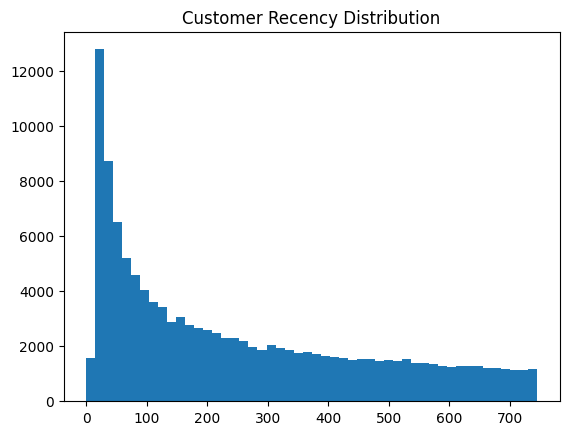

In [60]:
query = """
SELECT recency_days 
FROM master_customer_sql
WHERE recency_days IS NOT NULL
"""

df = pd.read_sql(query, engine)

plt.hist(df['recency_days'], bins=50)
plt.title("Customer Recency Distribution")
plt.show()

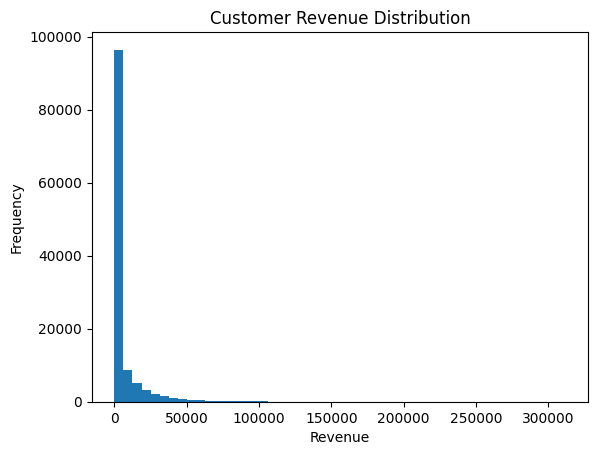

In [61]:
# Revenue distribution:
query = """
SELECT total_revenue 
FROM master_customer_sql
WHERE total_revenue IS NOT NULL
"""

df = pd.read_sql(query, engine)

plt.hist(df['total_revenue'], bins=50)
plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

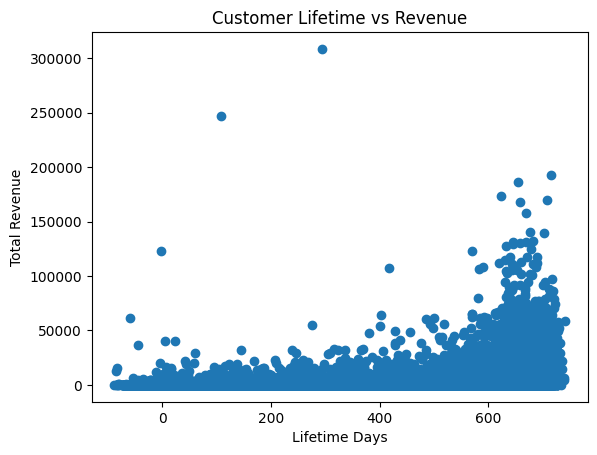

In [62]:
query = """
SELECT 
    customer_lifetime_days,
    total_revenue
FROM master_customer_sql
WHERE customer_lifetime_days IS NOT NULL 
AND total_revenue IS NOT NULL
"""

df = pd.read_sql(query, engine)

plt.scatter(df['customer_lifetime_days'], df['total_revenue'])
plt.title("Customer Lifetime vs Revenue")
plt.xlabel("Lifetime Days")
plt.ylabel("Total Revenue")
plt.show()

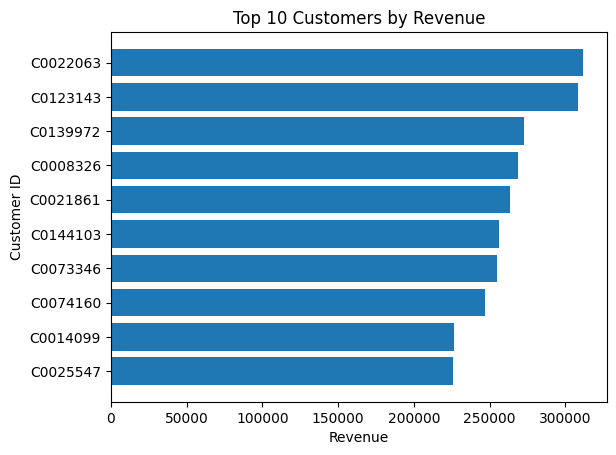

In [64]:
query = """
SELECT customer_id, total_revenue
FROM master_customer_sql
ORDER BY total_revenue DESC
LIMIT 10
"""

df = pd.read_sql(query, engine)

plt.barh(df['customer_id'], df['total_revenue'])
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.gca().invert_yaxis()
plt.show()

## Task 2: 
>## RFM segmetns:

In [68]:
query = """
select segment as Segments, count(*) as Customers
from rfm_segments
group by segment
"""

df = pd.read_sql(query, engine)
df.head()

,Segments,Customers
0,Lost Customers,36741
1,Potential Loyalists,11827
2,Loyal Customers,35387
3,At Risk,13586
4,Champions,23878


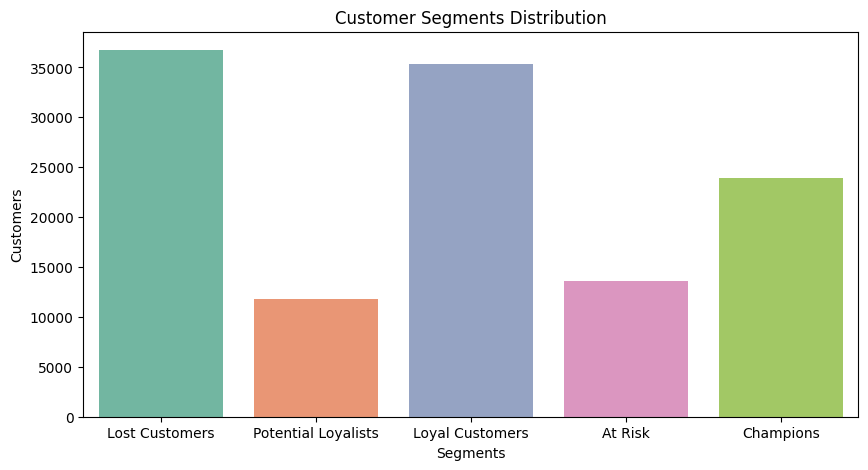

In [79]:
plt.figure(figsize=(10,5))
sns.barplot(data = df, x= 'Segments', y = 'Customers', palette='Set2')
plt.title('Customer Segments Distribution')
plt.show()

> ##  Acquisition channel vs The revenue:

In [81]:
#pd.read_sql("""select * from rfm_analysis""", engine)

In [82]:
query = """
select acquisition_channel, Avg(total_amount) as avg_revenue
from rfm_analysis
group by acquisition_channel
"""

df = pd.read_sql(query, engine)
df.head()

,acquisition_channel,avg_revenue
0,direct,825.603764
1,social_media,821.390895
2,organic_search,843.101104
3,paid_search,831.277009
4,email_campaign,821.832420


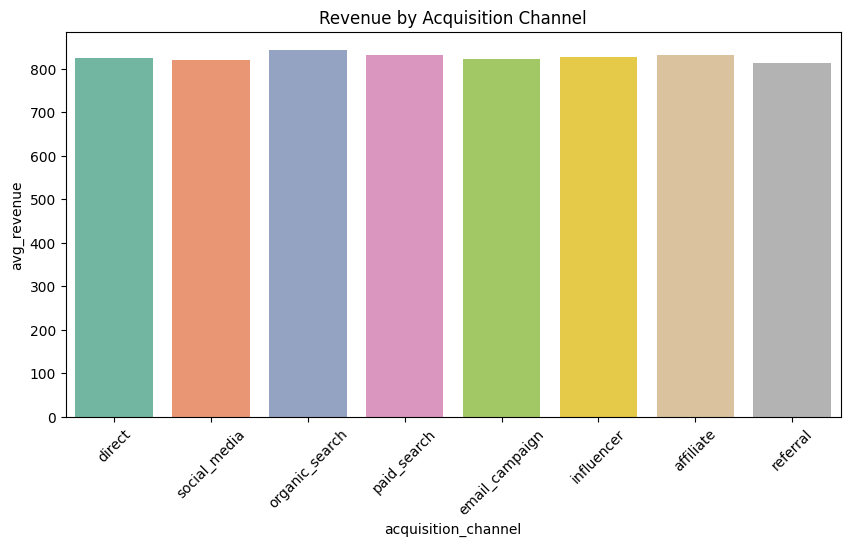

In [84]:
plt.figure(figsize=(10,5))
sns.barplot(data = df, x= 'acquisition_channel', y = 'avg_revenue', palette='Set2')
plt.title('Revenue by Acquisition Channel')
plt.xticks(rotation = 45)
plt.show()

In [87]:
# Geographic Distribution
query = """SELECT 
    country,
    COUNT(DISTINCT customer_id) AS customers
FROM rfm_analysis
GROUP BY country
ORDER BY customers desc
"""
df = pd.read_sql(query, engine)
df.head()
  

,country,customers
0,United States,33972
1,India,18173
2,UNITED KINGDOM,10916
3,Germany,9633
4,France,7302


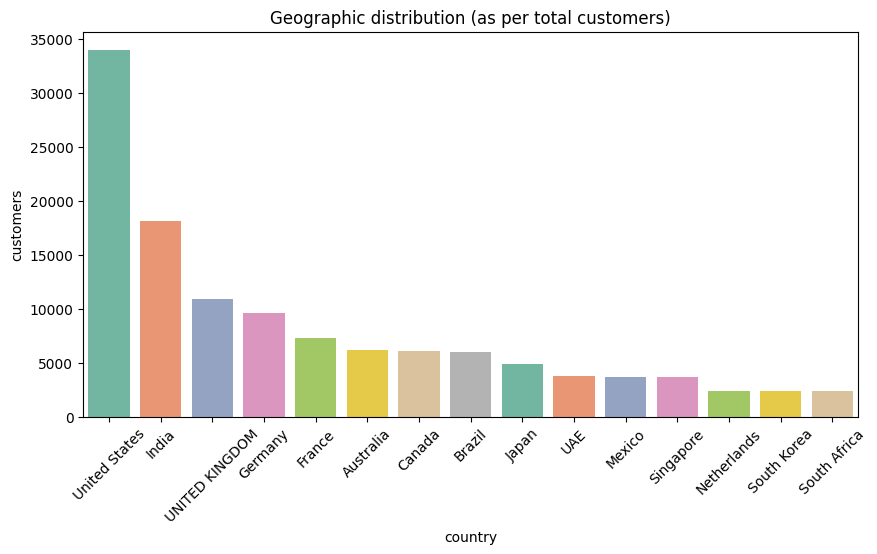

In [91]:
plt.figure(figsize=(10,5))
sns.barplot(data = df, x= 'country', y = 'customers', palette='Set2')
plt.title('Geographic distribution (as per total customers)')
plt.xticks(rotation = 45)
plt.show()

  purchase_timing       avg_ltv
0       Immediate  14502.372088
1           Early  12766.662425
2             Mid   8004.325040
3            Late   1938.964636


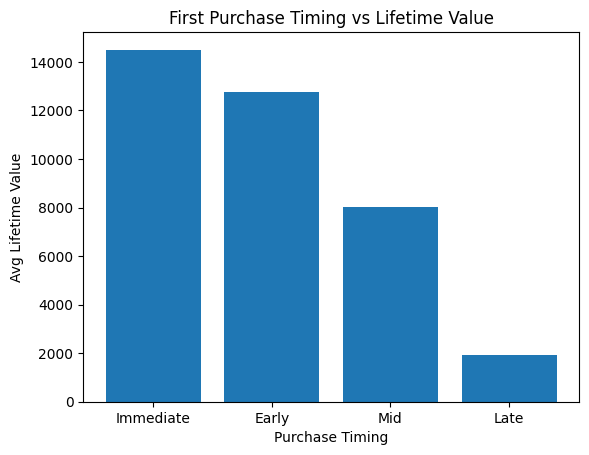

In [94]:
# Relationship between First puchase and the avg LTV
query = """
SELECT 
    CASE 
        WHEN days_to_first_purchase <= 1 THEN 'Immediate'
        WHEN days_to_first_purchase <= 7 THEN 'Early'
        WHEN days_to_first_purchase <= 30 THEN 'Mid'
        ELSE 'Late'
    END AS purchase_timing,
AVG(total_revenue) AS avg_ltv
FROM master_customer_sql
WHERE days_to_first_purchase IS NOT NULL
GROUP BY purchase_timing
ORDER BY avg_ltv desc
"""
df = pd.read_sql(query, engine)
print(df.head())

plt.bar(df['purchase_timing'], df['avg_ltv'])
plt.title("First Purchase Timing vs Lifetime Value")
plt.xlabel("Purchase Timing")
plt.ylabel("Avg Lifetime Value")
plt.show()

## Task -3: 

In [97]:
# MySQL connection
username = "root"
password = "ankit!mysql123"
#"your_password"
host = "localhost"
port = "3306"
database = "ecommerce_db"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [110]:
# best vs worst cohorts:
query = """
SELECT 
    cohort_month,
    cohort_size,
    d30 / cohort_size AS retention_30,
    d60 / cohort_size AS retention_60,
    d90 / cohort_size AS retention_90,
    d120 / cohort_size AS retention_120,
    d150 / cohort_size AS retention_150,
    d180 / cohort_size AS retention_180
FROM cohort_retention
ORDER BY cohort_month;
"""

df = pd.read_sql(query, engine)
df.head()

,cohort_month,cohort_size,retention_30,retention_60,retention_90,retention_120,retention_150,retention_180
0,2024-01-01,6319,0.1429,0.2230,0.2812,0.3328,0.3759,0.4129
1,2024-02-01,5970,0.1531,0.2305,0.2868,0.3370,0.3740,0.4109
2,2024-03-01,6156,0.1465,0.2269,0.2828,0.3285,0.3683,0.4038


In [111]:
df['retention_90'].rank(ascending=False)

0    3.0
1    1.0
2    2.0
Name: retention_90, dtype: float64

In [112]:
# on the basis of 90 day retenion period:
df['retention_90_rank'] = df['retention_90'].rank(ascending=False)

best_cohort = df.loc[df['retention_90'].idxmax()]
worst_cohort = df.loc[df['retention_90'].idxmin()]

print("Best Cohort:\n", best_cohort)
print("\nWorst Cohort:\n", worst_cohort)

Best Cohort:
 cohort_month         2024-02-01
cohort_size                5970
retention_30             0.1531
retention_60             0.2305
retention_90             0.2868
retention_120             0.337
retention_150             0.374
retention_180            0.4109
retention_90_rank           1.0
Name: 1, dtype: object

Worst Cohort:
 cohort_month         2024-01-01
cohort_size                6319
retention_30             0.1429
retention_60              0.223
retention_90             0.2812
retention_120            0.3328
retention_150            0.3759
retention_180            0.4129
retention_90_rank           3.0
Name: 0, dtype: object


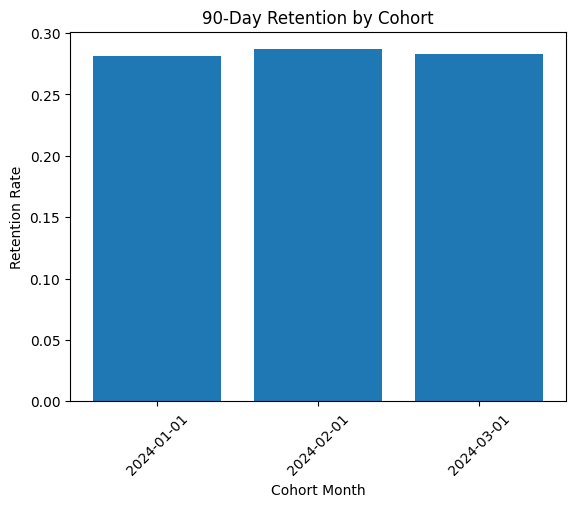

In [113]:
plt.figure()
plt.bar(df['cohort_month'], df['retention_90'])
plt.xticks(rotation=45)
plt.title("90-Day Retention by Cohort")
plt.xlabel("Cohort Month")
plt.ylabel("Retention Rate")
plt.show()

In [104]:
query = """
SELECT * FROM cohort_retention
ORDER BY cohort_month
"""

df = pd.read_sql(query, engine)
df.head()

,cohort_month,cohort_size,d30,d60,d90,d120,d150,d180
0,2024-01-01,6319,903,1409,1777,2103,2375,2609
1,2024-02-01,5970,914,1376,1712,2012,2233,2453
2,2024-03-01,6156,902,1397,1741,2022,2267,2486


In [105]:
df_melted = df.melt(
    id_vars='cohort_month',
    value_vars=['d30', 'd60', 'd90', 'd120', 'd150', 'd180'],
    var_name='day_bucket',
    value_name='customers_retained'
)
# Extract numeric day (30, 60, etc.)
df_melted['days'] = df_melted['day_bucket'].str.extract('(\d+)').astype(int)

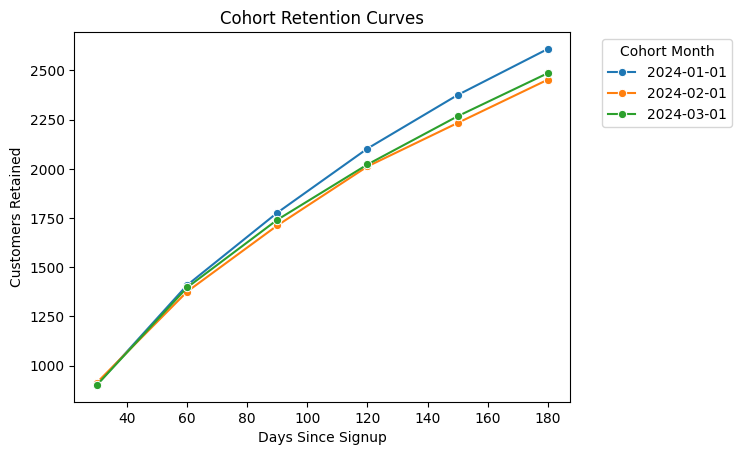

In [107]:
plt.figure()
sns.lineplot(data=df_melted,x='days', y='customers_retained', hue='cohort_month',marker='o')
plt.title("Cohort Retention Curves")
plt.xlabel("Days Since Signup")
plt.ylabel("Customers Retained")
plt.legend(title="Cohort Month", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

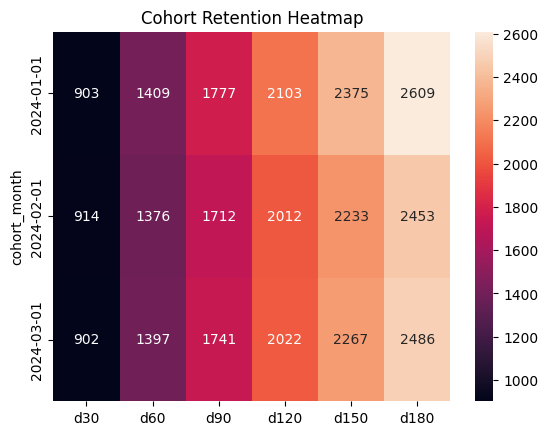

In [108]:
heatmap_data = df.set_index('cohort_month')[['d30','d60','d90','d120','d150','d180']]
sns.heatmap(heatmap_data, annot=True, fmt=".0f")
plt.title("Cohort Retention Heatmap")
plt.show()

In [114]:
# March 2024 cohort analysis:
df

,cohort_month,cohort_size,retention_30,retention_60,retention_90,retention_120,retention_150,retention_180,retention_90_rank
0,2024-01-01,6319,0.1429,0.2230,0.2812,0.3328,0.3759,0.4129,3.0
1,2024-02-01,5970,0.1531,0.2305,0.2868,0.3370,0.3740,0.4109,1.0
2,2024-03-01,6156,0.1465,0.2269,0.2828,0.3285,0.3683,0.4038,2.0


In [115]:
march_cohort = df[df['cohort_month'] == '2024-03-01']

other_cohorts = df[df['cohort_month'] != '2024-03-01']

avg_others = other_cohorts.mean(numeric_only=True)

print("March Cohort:\n", march_cohort)
print("\nAverage of Other Cohorts:\n", avg_others)

March Cohort:
   cohort_month  cohort_size  retention_30  retention_60  retention_90  \
2   2024-03-01         6156        0.1465        0.2269        0.2828   

   retention_120  retention_150  retention_180  retention_90_rank  
2         0.3285         0.3683         0.4038                2.0  

Average of Other Cohorts:
 cohort_size          6144.50000
retention_30            0.14800
retention_60            0.22675
retention_90            0.28400
retention_120           0.33490
retention_150           0.37495
retention_180           0.41190
retention_90_rank       2.00000
dtype: float64


In [116]:
avg_others

cohort_size          6144.50000
retention_30            0.14800
retention_60            0.22675
retention_90            0.28400
retention_120           0.33490
retention_150           0.37495
retention_180           0.41190
retention_90_rank       2.00000
dtype: float64

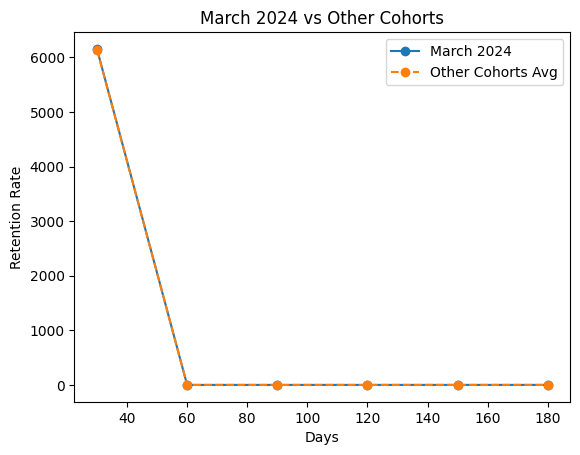

In [117]:
plt.figure()
plt.plot(
    [30, 60, 90, 120, 150, 180],
    march_cohort.iloc[0][1:7],marker='o',
    label='March 2024')

plt.plot(
    [30, 60, 90, 120, 150, 180],
    avg_others[0:6],
    marker='o',
    linestyle='--',
    label='Other Cohorts Avg')
plt.title("March 2024 vs Other Cohorts")
plt.xlabel("Days")
plt.ylabel("Retention Rate")
plt.legend()
plt.show()

## Task 4:

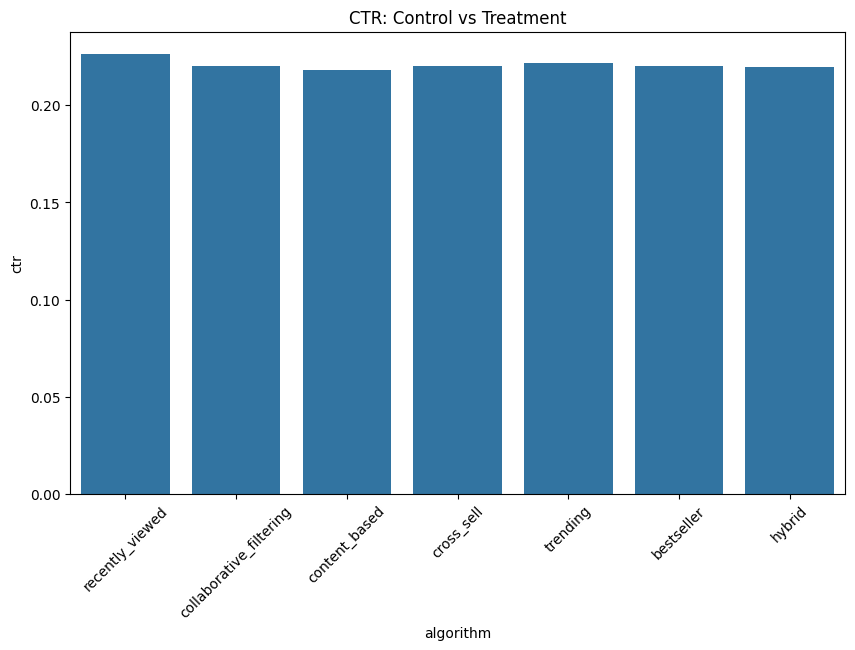

In [124]:
query = """
SELECT 
    algorithm,
    SUM(clicked)/COUNT(*) AS ctr
FROM recommendation_clean
GROUP BY algorithm
"""

df = pd.read_sql(query, engine)
plt.figure(figsize = (10,6))
sns.barplot(data=df, x='algorithm', y='ctr')
plt.title("CTR: Control vs Treatment")
plt.xticks(rotation = 45)
plt.show()

In [129]:
pd.read_sql('''select * from recommendation_clean''', engine)

,exposure_id,customer_id,product_id,recommendation_id,algorithm,position,page_context,clicked,purchased,exposure_date,session_id
0,EXP00000001,C0068826,P00027,REC231318,recently_viewed,4,cart,0,0,2025-12-27 19:41:49,sess-NOLQ-77966371
1,EXP00000002,C0099314,P03068,REC749950,collaborative_filtering,1,homepage,0,0,2025-10-08 21:04:23,sess-btLC-37928713
2,EXP00000003,C0135459,P00335,REC912686,collaborative_filtering,1,checkout,0,0,2024-04-07 01:31:22,sess-Taxd-30203272
3,EXP00000004,C0003591,P01603,REC447792,recently_viewed,7,cart,1,1,2024-10-02 00:36:48,sess-FhSH-44535370
4,EXP00000005,C0019645,P02282,REC210504,collaborative_filtering,10,search,0,0,2025-06-23 02:28:55,sess-eqaA-23999806
...,...,...,...,...,...,...,...,...,...,...,...
399995,EXP00399996,C0136053,P02123,REC826611,trending,6,homepage,0,0,2025-09-02 18:42:42,sess-eCIH-83310450
399996,EXP00399997,C0021129,P04361,REC239752,content_based,3,checkout,0,0,2024-08-19 14:09:27,sess-ZxIH-69919201
399997,EXP00399998,C0086206,P01698,REC813541,content_based,4,homepage,1,0,2025-08-05 01:01:33,sess-wUjx-45142333
399998,EXP00399999,C0083632,P02256,REC480456,trending,3,cart,0,0,2025-04-01 02:11:17,sess-qoSb-58394359


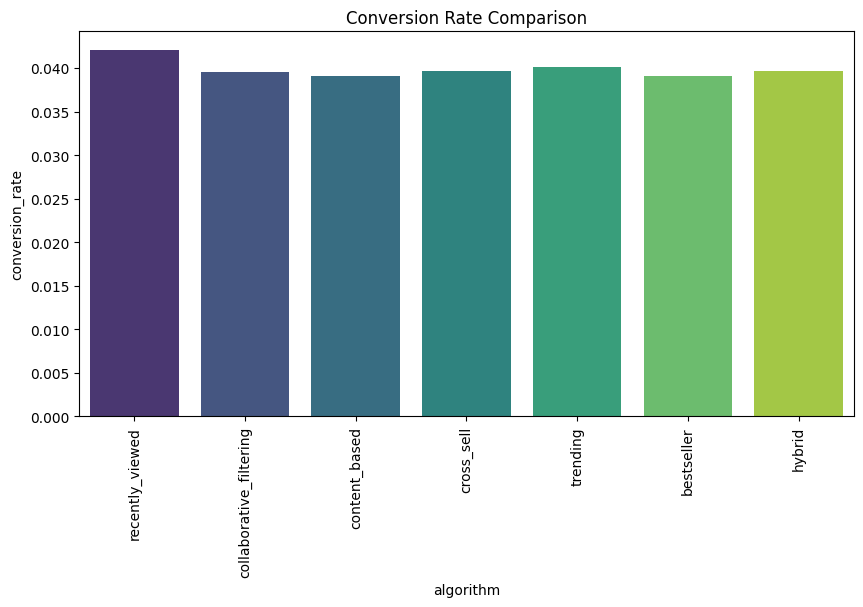

In [128]:
query = """
select 
    algorithm, sum(purchased)/COUNT(*) AS conversion_rate
from recommendation_clean
GROUP BY algorithm
"""

df = pd.read_sql(query, engine)
plt.figure(figsize = (10,5))
sns.barplot(data=df, x='algorithm', y='conversion_rate', palette='viridis')
plt.title("Conversion Rate Comparison")
plt.xticks(rotation = 90)
plt.show()

In [132]:
# statistical test:
query = """
SELECT 
    algorithm,SUM(clicked) AS clicks, COUNT(*) AS exposures
FROM recommendation_clean
GROUP BY algorithm
"""

df = pd.read_sql(query, engine)
df['ctr'] = df['clicks'] / df['exposures']
df.sort_values('ctr', ascending=False)

,algorithm,clicks,exposures,ctr
0,recently_viewed,12859.0,56746,0.226606
4,trending,12719.0,57366,0.221717
5,bestseller,12640.0,57341,0.220436
1,collaborative_filtering,12602.0,57215,0.220257
3,cross_sell,12626.0,57336,0.220211
6,hybrid,12501.0,56931,0.219582
2,content_based,12460.0,57065,0.218347


In [133]:
from scipy.stats import chi2_contingency

'''
H0: all algorithm have same ctr
HA: at leat 1 algorithm has diffrent ctr
'''

# clicks and non-clicks
clicks = df['clicks'].values
non_clicks = df['exposures'] - df['clicks']

# contingency table
contingency_table = np.array([clicks, non_clicks])
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square stat:", chi2)
print("P-value:", p_value)

if p_value < 0.05: # CI = 95%
    print("Reject H0,Statistically significant difference across algorithms")
else:
    print("No significant difference")

[[12859. 12602. 12460. 12626. 12719. 12640. 12501.]
 [43887. 44613. 44605. 44710. 44647. 44701. 44430.]]
Chi-square stat: 14.024039930643953
P-value: 0.02936877430284957
Reject H0,Statistically significant difference across algorithms


## Download the table from database:

In [134]:
customers = pd.read_sql("SELECT * FROM customers_clean", engine)
transactions = pd.read_sql("SELECT * FROM transactions_clean", engine)
products = pd.read_sql("SELECT * FROM products_clean", engine)
master_customer = pd.read_sql("SELECT * FROM master_customer_sql", engine)

In [ ]:
# customers.to_csv("customers.csv", index=False)
# transactions.to_csv("transactions.csv", index=False)
# products.to_csv("products.csv", index=False)
# master_customer.to_csv("master_customer.csv", index=False)

# Bonus Questions:

In [138]:
# Revenue per customer per channel
query = """
SELECT 
    c.customer_id,
    c.acquisition_channel,
    SUM(t.total_amount) AS revenue
FROM customers_clean c
JOIN transactions_clean t
ON c.customer_id = t.customer_id
GROUP BY c.customer_id, c.acquisition_channel
"""

df = pd.read_sql(query, engine)

# avg revenue per channel
channel_perf = df.groupby('acquisition_channel')['revenue'].mean()
print(channel_perf)

acquisition_channel
affiliate         5468.486741
direct            5520.294852
email_campaign    5458.289797
influencer        5244.281701
organic_search    5501.878555
paid_search       5516.376470
referral          5354.239124
social_media      5418.473368
Name: revenue, dtype: float64


In [140]:
query = """SELECT 
    customer_id,
    total_transactions,
    total_revenue,
    avg_order_value,
    recency_days,
    customer_lifetime_days,
    is_repeat_customer,
    is_churned
FROM master_customers;
"""
df = pd.read_sql(query, engine)
df.head()

,customer_id,total_transactions,total_revenue,avg_order_value,recency_days,customer_lifetime_days,is_repeat_customer,is_churned
0,C0000001,NaN,NaN,NaN,NaN,NaN,0,0
1,C0000002,4.0,693.95,173.4875,-398.0,NaN,1,0
2,C0000003,NaN,NaN,NaN,NaN,NaN,0,0
3,C0000004,5.0,486.14,97.2280,-433.0,NaN,1,0
4,C0000005,1.0,99.20,99.2000,-56.0,NaN,0,0


In [148]:
df['recency_days'] = df['recency_days'].abs()

In [150]:
#Impute numeric columns with median
numeric_cols = ['total_transactions', 'total_revenue', 'avg_order_value', 'recency_days', 'customer_lifetime_days']

medians = df[numeric_cols].median()
print("\nMedians used for imputation:\n", medians)

df[numeric_cols] = df[numeric_cols].fillna(medians)


Medians used for imputation:
 total_transactions          2.00
total_revenue             284.63
avg_order_value           134.08
recency_days              469.00
customer_lifetime_days    511.00
dtype: float64


In [154]:
df = df[df['total_transactions'] > 0]

In [155]:
print(f"\nRows after cleaning: {len(df)}")
print("NaN counts after cleaning:\n", df.isna().sum())


Rows after cleaning: 150000
NaN counts after cleaning:
 customer_id               0
total_transactions        0
total_revenue             0
avg_order_value           0
recency_days              0
customer_lifetime_days    0
is_repeat_customer        0
is_churned                0
dtype: int64


In [156]:
df.head()

,customer_id,total_transactions,total_revenue,avg_order_value,recency_days,customer_lifetime_days,is_repeat_customer,is_churned
0,C0000001,2.0,284.63,134.0800,469.0,511.0,0,0
1,C0000002,4.0,693.95,173.4875,398.0,511.0,1,0
2,C0000003,2.0,284.63,134.0800,469.0,511.0,0,0
3,C0000004,5.0,486.14,97.2280,433.0,511.0,1,0
4,C0000005,1.0,99.20,99.2000,56.0,511.0,0,0


In [160]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,roc_auc_score

In [158]:
features = ['total_transactions', 'total_revenue', 'avg_order_value', 
            'recency_days', 'customer_lifetime_days', 'is_repeat_customer']

X = df[features]
y = df['is_churned']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [161]:
# --- Random Forest (Recommended - better performance) ---
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

print("\n Random Forest Model Performance:")
print(classification_report(y_test, rf.predict(X_test)))
print("AUC Score:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop Feature Importances:")
print(importances)


 Random Forest Model Performance:
              precision    recall  f1-score   support

           0       0.80      0.96      0.88     30101
           1       0.19      0.04      0.06      7399

    accuracy                           0.78     37500
   macro avg       0.50      0.50      0.47     37500
weighted avg       0.68      0.78      0.71     37500

AUC Score: 0.5006428800126568

Top Feature Importances:
total_revenue             0.305248
avg_order_value           0.304729
recency_days              0.297277
customer_lifetime_days    0.045854
total_transactions        0.044832
is_repeat_customer        0.002061
dtype: float64


In [162]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train, y_train)
print("\nLogistic Regression AUC:", roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1]))


Logistic Regression AUC: 0.5038291794298385


In [163]:
# Anlalyze CHURN RISK On Full dataset
df['churn_probability'] = rf.predict_proba(X)[:, 1]

# Top 1000 customers at highest risk of churn
top_1000_risk = df.nlargest(1000, 'churn_probability')[
    ['customer_id', 'churn_probability', 'total_revenue', 'recency_days', 
     'total_transactions', 'customer_lifetime_days', 'is_repeat_customer']
].reset_index(drop=True)

print("\nTop 5 Highest Risk Customers:")
print(top_1000_risk.head())


Top 5 Highest Risk Customers:
  customer_id  churn_probability  total_revenue  recency_days  \
0    C0070096           0.960000         185.82         533.0   
1    C0090483           0.960000         185.84         533.0   
2    C0076842           0.953333          69.21           7.0   
3    C0103463           0.943333          27.80         448.0   
4    C0044260           0.936667          47.76         241.0   

   total_transactions  customer_lifetime_days  is_repeat_customer  
0                 2.0                   511.0                   1  
1                 2.0                   511.0                   1  
2                 1.0                   511.0                   0  
3                 1.0                   511.0                   0  
4                 2.0                   511.0                   1  


In [167]:
df[['is_churned', 'churn_probability']].sample(10)

,is_churned,churn_probability
65824,0,0.126667
85958,0,0.023333
72862,1,0.746667
83206,0,0.006667
41932,0,0.816667
53344,0,0.050000
92560,1,0.640000
139645,1,0.210000
46277,0,0.240000
15984,0,0.370000


In [168]:
# DYNAMIC PRICING IMPACT:
transactions['price_bucket'] = pd.qcut(
    transactions['unit_price'], 
    q=5, 
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)


In [169]:
conversion = transactions.groupby('price_bucket').agg({
    'transaction_id': 'count',
    'status': lambda x: (x == 'completed').sum()
}).rename(columns={'transaction_id': 'total', 'status': 'converted'})

conversion['conversion_rate'] = conversion['converted'] / conversion['total']

print(conversion)

               total  converted  conversion_rate
price_bucket                                    
Very Low      160047      88236         0.551313
Low           159987      88374         0.552382
Medium        160123      88394         0.552038
High          159896      88604         0.554135
Very High     159947      88322         0.552195


In [170]:
# discount impact:a
transactions['has_discount'] = transactions['discount_code'].notna()

discount_analysis = transactions.groupby('has_discount').agg({
    'transaction_id': 'count',
    'total_amount': 'sum'
})

print(discount_analysis)

              transaction_id  total_amount
has_discount                              
False                 532114  4.407310e+08
True                  267886  2.222198e+08


In [171]:
transactions['discount_flag'] = transactions['discount_code'].notna()

group = transactions.groupby('discount_flag')['total_amount'].mean()
print(group)

discount_flag
False    828.264192
True     829.531061
Name: total_amount, dtype: float64
